# 3.Clasificación de Aditivos mediante Machine Learning No Supervisado

Este cuaderno detalla el proceso de análisis multivariante y segmentación de una base de datos de aditivos alimentarios enriquecida con evidencia científica de PubMed.

### 1. Configuración del Entorno
Se importan las herramientas esenciales para el flujo de trabajo de Ciencia de Datos:
* **Procesamiento**: `pandas` para la gestión de dataframes y `numpy` para operaciones numéricas.
* **Visualización**: `matplotlib.plt` y `seaborn` para la creación de gráficos estadísticos y `matplotlib.cm` para el mapeo de colores en clusters.
* **Modelado (Scikit-Learn)**:
    * `StandardScaler`: Normalización de métricas científicas (cargas de toxicidad).
    * `KMeans`: Algoritmo de agrupamiento no supervisado.
    * `PCA`: Reducción de dimensiones para inspección visual.
    * `silhouette_score`: Métrica de validación de la calidad del agrupamiento.


In [25]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Machine Learning (Scikit-Learn)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

### 2. Ingeniería de Características y Preprocesamiento
Antes del entrenamiento, los datos pasan por una fase de refinamiento:
* **Selección de Variables**: Se utilizan las dimensiones de riesgo obtenidas de PubMed (como toxicidad genética, carcinogenicidad, etc.) y se excluyen los identificadores no numéricos como `id_original`.
* **Escalado Logarítmico**: Se aplica `np.log1p` para manejar el sesgo de los conteos de PubMed, donde unos pocos aditivos tienen miles de citas y muchos otros muy pocas.
* **Estandarización**: Se centra la media en 0 y la varianza en 1 para que ninguna dimensión científica domine injustamente el modelo.

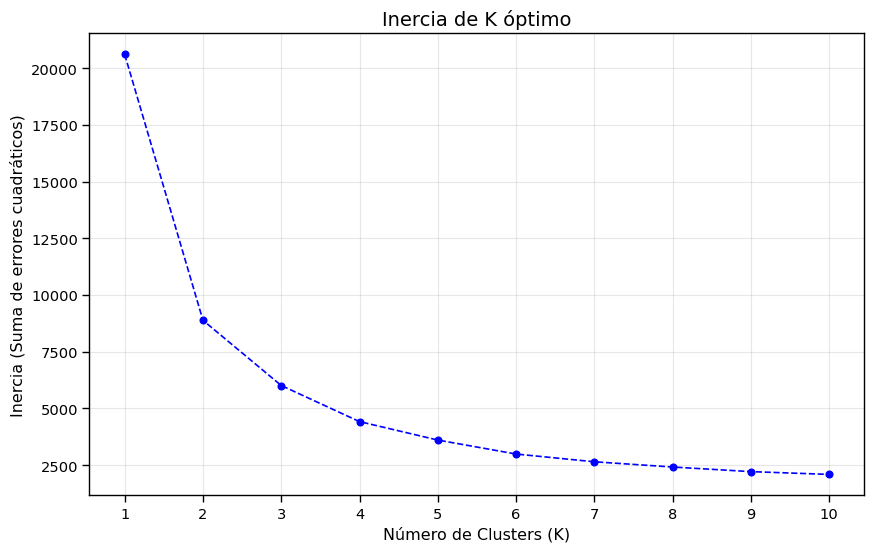

Inercia para K=2: 8887.25
Inercia para K=3: 6012.34
Inercia para K=4: 4420.92
Inercia para K=5: 3607.98


In [26]:
# 1. Cargar el dataset de aditivos
df_pubmed = pd.read_csv('../data/dataset_final_con_codigos.csv')


# Seleccionar columnas numéricas para el clustering
features = df_pubmed.columns.drop(['id_original', 'nombre_referencia', 'codigo_e', 'id'])
X = df_pubmed[features]

# Preprocesamiento: Log-scaling + StandardScaler
X_log = np.log1p(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Calcular la inercia para el Método del Codo (Elbow Method)
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualización del Método del Codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Inercia de K óptimo', fontsize=14)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Suma de errores cuadráticos)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/plots/aditives/metodo_codo.png')
plt.show()

print(f"Inercia para K=2: {inertia[1]:.2f}")
print(f"Inercia para K=3: {inertia[2]:.2f}")
print(f"Inercia para K=4: {inertia[3]:.2f}")
print(f"Inercia para K=5: {inertia[4]:.2f}")

Para n_clusters = 2, el promedio de silhouette es: 0.5510


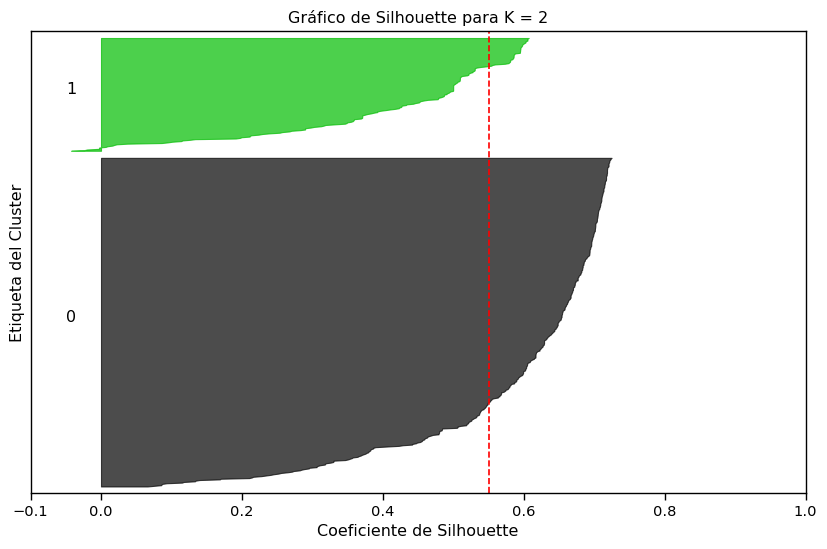

Para n_clusters = 3, el promedio de silhouette es: 0.3956


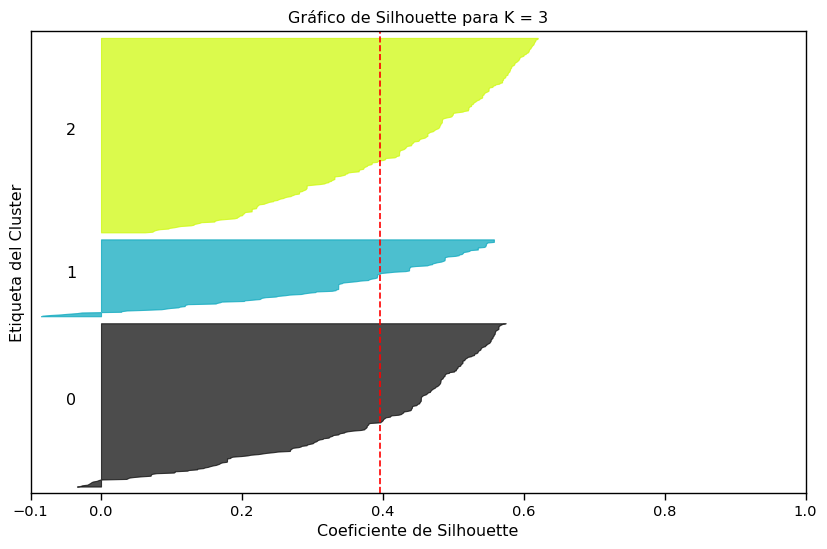

Para n_clusters = 4, el promedio de silhouette es: 0.4059


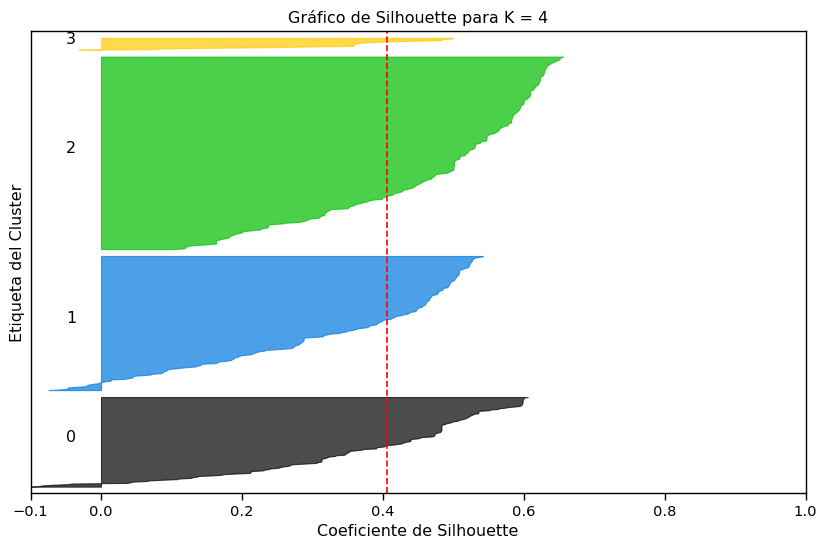

In [27]:
# Vamos a evaluar Silhouette para k=2, k=3 y k=4 que eran nuestros candidatos
range_n_clusters = [2, 3, 4]

for n_clusters in range_n_clusters:
    # Crear un subplot: 1 fila, 2 columnas (Silhouette y el scatter)
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(10, 6)

    # El coeficiente de silhouette va de -1 a 1
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    # Entrenar K-means
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X_scaled)

    # El silhouette_score da el promedio de todos los ejemplos
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"Para n_clusters = {n_clusters}, el promedio de silhouette es: {silhouette_avg:.4f}")

    # Calcular los scores de silhouette para cada muestra
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Etiquetar los clusters en el centro
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # Espacio entre siluetas

    ax1.set_title(f"Gráfico de Silhouette para K = {n_clusters}")
    ax1.set_xlabel("Coeficiente de Silhouette")
    ax1.set_ylabel("Etiqueta del Cluster")

    # Línea vertical para el promedio
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])  # Limpiar y-axis
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    
    plt.savefig(f'../outputs/plots/aditives/silhouette_k{n_clusters}.png')
    plt.show()

### 3. Optimización del Modelo (K-Means)
El cuaderno implementa una búsqueda del número óptimo de clusters ($K$):
* **Método del Codo**: Se analiza la reducción de la inercia.
* **Análisis de Silhouette**: Se evalúa la cohesión. Los resultados indican que **K=3** proporciona una estructura equilibrada para segmentar el riesgo químico de los aditivos.

In [28]:
# 3. Aplicar el modelo K-Means definitivo
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_pubmed['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Crear el dataset simplificado: Solo identificadores y cluster
# Aquí quitamos todas las dimensiones de PubMed
df_taxonomia = df_pubmed[['id_original', 'nombre_referencia', 'cluster', 'id']].copy()

# 5. Guardar el archivo puente
df_taxonomia.to_csv('../data/taxonomia_final_aditivos.csv', index=False)

print("✅ Taxonomía simplificada generada exitosamente.")
print(df_taxonomia.head())

✅ Taxonomía simplificada generada exitosamente.
   id_original         nombre_referencia  cluster         id
0            0         Dicalcium citrate        0  en:e333ii
1            1  Butylated hydroxytoluene        1    en:e321
2            2         Magnesium citrate        0    en:e345
3            3       Potassium ascorbate        0    en:e303
4            4                    lipase        1   en:e1104


### 4. Visualización del Mapa Maestro

Se comparan las **Medianas** por cada cluster para comprovar si la separación ha sido buena y se hace un pie plot para ver cuantos aditivos han quedado por cluster

In [29]:
# --- Análisis del Top 8 de medianas por Cluster ---

# 1. Asegurar limpieza de duplicados (basado en tu código previo)
df_pubmed = df_pubmed.loc[:, ~df_pubmed.columns.duplicated()].copy()
columnas_no_deseadas = ['id_original', 'nombre_referencia', 'codigo_e', 'id', 'PCA1', 'PCA2', 'cluster', 'actividad_antimicrobiana', 'nanoparticulas', 'valor_prebiotico', 'citoproteccion_salud','toxicidad_emulsionantes', 'toxicidad_conservadores', 'antioxidante_tecnico', 'total_docs']
features_para_mediana = [c for c in df_pubmed.columns if c not in columnas_no_deseadas]

# 2. Cálculo de la mediana agrupada
variables_analisis = features_para_mediana + ['cluster']
df_perfil_clusters = df_pubmed[variables_analisis].groupby('cluster').median(numeric_only=True)

# 3. Extraer el Top 5 de cada cluster
top_features = set()
for cluster in df_perfil_clusters.index:
    # Ordenar las variables de este cluster de mayor a menor y tomar las primeras 8
    top = df_perfil_clusters.loc[cluster].nlargest(24).index
    top_features.update(top)

# 4. Filtrar la tabla original de medianas solo con estas variables destacadas
# Transponemos para que las variables queden en las filas
df_top_medianas = df_perfil_clusters[list(top_features)].T

print("--- Top de Dimensiones con mayores medianas por Cluster ---")
display(df_top_medianas)

--- Top de Dimensiones con mayores medianas por Cluster ---


cluster,0,1
neurotoxicidad,495.0,2064.0
toxicidad_edulcorantes,1.0,5.0
inflamacion_pro,999.0,4132.5
nefrotoxicidad,400.0,1416.5
autoinmunidad,474.0,1698.0
alergia_inmune,594.0,2490.0
cardiotoxicidad,754.0,2917.0
microbiota_dysbiosis,62.0,285.5
barrera_hematoencefalica,418.0,1637.5
epigenetica,482.0,2295.0


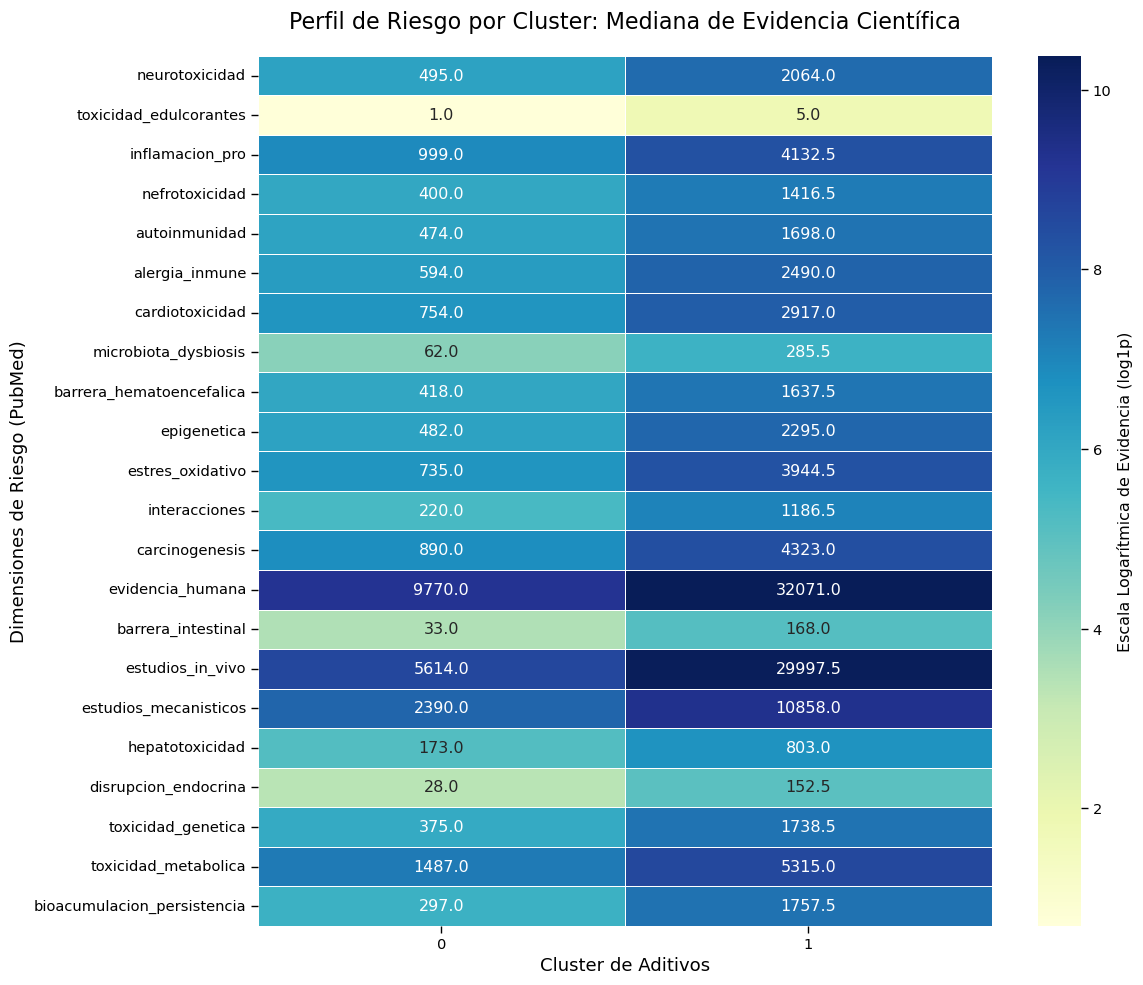

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Transformación logarítmica (log1p maneja ceros correctamente)
# Esto normaliza visualmente las diferencias entre dimensiones masivas y pequeñas
df_heatmap_data = np.log1p(df_top_medianas)

# 2. Configuración de estilo
plt.figure(figsize=(12, 10))
sns.set_context("paper", font_scale=1.2)

# 3. Creación del Heatmap corregido
sns.heatmap(df_heatmap_data, 
            annot=df_top_medianas,    # Valores reales (sin log) en las celdas
            fmt=".1f",                # Un decimal para mayor claridad
            cmap="YlGnBu",            # Escala de colores (claro=seguro, oscuro=riesgo)
            linewidths=.5,            # Separación entre celdas
            cbar_kws={'label': 'Escala Logarítmica de Evidencia (log1p)'}) # Etiqueta corregida

# 4. Personalización de títulos y ejes
plt.title('Perfil de Riesgo por Cluster: Mediana de Evidencia Científica', fontsize=16, pad=20)
plt.xlabel('Cluster de Aditivos', fontsize=13)
plt.ylabel('Dimensiones de Riesgo (PubMed)', fontsize=13)

plt.tight_layout()
plt.show()

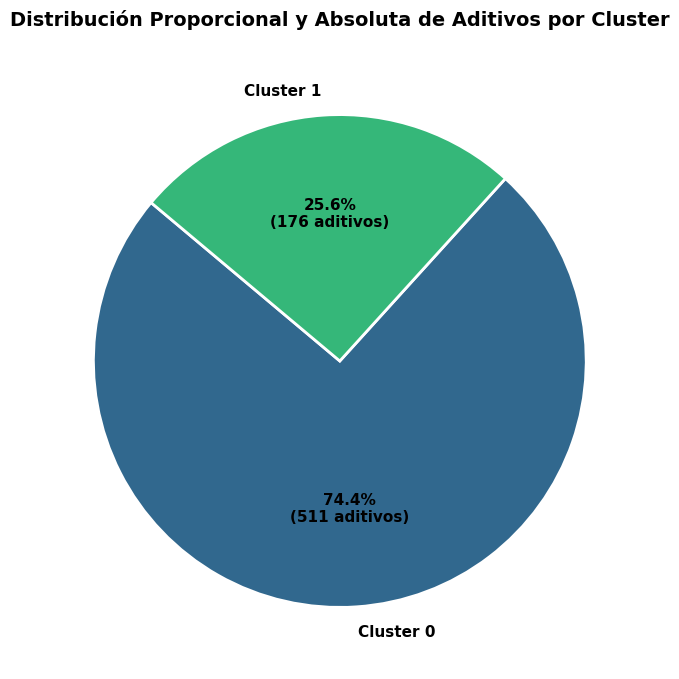

In [31]:
# --- Generar el Gráfico de Tarta (Pie Chart) de los Clusters ---

# 1. Obtener la distribución de los aditivos de forma dinámica
counts = df_pubmed['cluster'].value_counts().sort_index()
labels = [f'Cluster {i}' for i in counts.index]

# 2. Función interna para calcular el número absoluto a partir del porcentaje
def fmt_valores(pct):
    total = sum(counts)
    absoluto = int(round(pct * total / 100.0))
    return f'{pct:.1f}%\n({absoluto} aditivos)'

# 3. Crear el gráfico orientado a objetos (más limpio y robusto)
fig, ax = plt.subplots(figsize=(8, 8))
colores = sns.color_palette('viridis', len(counts))

ax.pie(
    counts, 
    labels=labels, 
    autopct=fmt_valores, 
    startangle=140, 
    colors=colores,
    textprops={'fontsize': 11, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True}
)

ax.set_title('Distribución Proporcional y Absoluta de Aditivos por Cluster', fontsize=14, pad=20, weight='bold')

# 4. Guardar el gráfico automáticamente en tu ruta de almacenamiento
plt.savefig('../outputs/plots/aditives/pie_chart_clusters.png', bbox_inches='tight', dpi=300)

Se genera un **Biplot de PCA** que permite:
* Visualizar la dispersión de los aditivos en un plano bidimensional.
* Cuantificar el peso de cada variable: Al calcular los loadings (coeficientes), se determina qué porcentaje de la varianza total del riesgo es explicado por factores metabólicos, neurológicos o celulares.

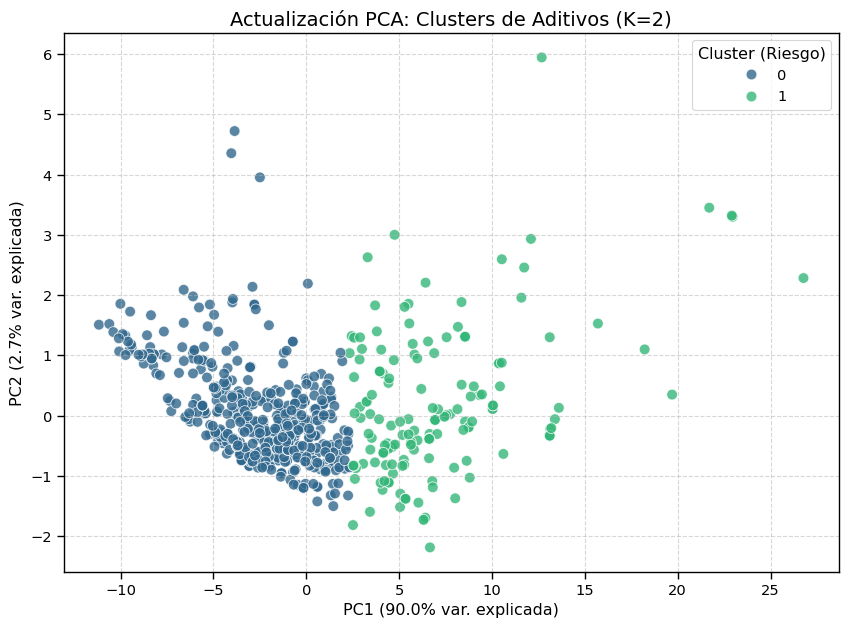

--- Distribución de Aditivos por Cluster ---
cluster
0    511
1    176
Name: count, dtype: int64


In [32]:
# 1. Preparar datos
features = df_pubmed.columns.drop(['id_original', 'nombre_referencia', 'codigo_e', 'id', 'cluster'])
X = df_pubmed[features]
# Aplicar logaritmo y escalado estándar (el método que dio la mejor distribución)
X_log = np.log1p(X)
X_scaled = StandardScaler().fit_transform(X_log)

# 2. Ejecutar K-Means con K=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_pubmed['cluster'] = kmeans.fit_predict(X_scaled)

# 3. Actualización de PCA: Visualización de Clusters en 2D
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)
df_pubmed['PCA1'] = pca_results[:, 0]
df_pubmed['PCA2'] = pca_results[:, 1]

# Generar el gráfico de dispersión actualizado
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=df_pubmed, palette='viridis', s=60, alpha=0.8)
plt.title('Actualización PCA: Clusters de Aditivos (K=2)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var. explicada)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var. explicada)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Cluster (Riesgo)')
plt.savefig('../outputs/plots/aditives/pca_actualizado_clusters.png')
plt.show()


# Imprimir distribución para verificar equilibrio
print("--- Distribución de Aditivos por Cluster ---")
print(df_pubmed['cluster'].value_counts().sort_index())

In [33]:
# 1. Ejecutar PCA
pca = PCA(n_components=3)
pca.fit(X_scaled)

# 2. Obtener la varianza explicada
# Esto devuelve un array con el % de varianza de cada componente
explained_variance = pca.explained_variance_ratio_

# 3. Obtener las cargas (loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(3)],
    index=features
)

print("--- Resumen de Varianza Explicada ---")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1} explica el {var*100:.2f}% de la varianza total.")

print(f"\nVarianza total acumulada (3 PCs): {sum(explained_variance)*100:.2f}%")

print("\n--- Dimensiones con mayor peso en cada Componente Principal ---")
for i, col in enumerate(loadings.columns):
    # Añadimos el % de varianza al encabezado para dar contexto
    print(f"\n{col} ({explained_variance[i]*100:.1f}% var. expl.):")
    
    top_features = loadings[col].sort_values(ascending=False)
    significant = top_features[abs(top_features) > 0.1]
    
    for feat, val in significant.items():
        print(f"  - {feat}: {val:.3f}")

--- Resumen de Varianza Explicada ---
PC1 explica el 89.99% de la varianza total.
PC2 explica el 2.68% de la varianza total.
PC3 explica el 1.48% de la varianza total.

Varianza total acumulada (3 PCs): 94.15%

--- Dimensiones con mayor peso en cada Componente Principal ---

PC1 (90.0% var. expl.):
  - estudios_mecanisticos: 0.190
  - carcinogenesis: 0.190
  - inflamacion_pro: 0.190
  - estudios_in_vivo: 0.189
  - citoproteccion_salud: 0.189
  - neurotoxicidad: 0.189
  - bioacumulacion_persistencia: 0.189
  - actividad_antimicrobiana: 0.189
  - epigenetica: 0.188
  - toxicidad_genetica: 0.188
  - toxicidad_metabolica: 0.188
  - estres_oxidativo: 0.187
  - barrera_hematoencefalica: 0.187
  - nefrotoxicidad: 0.186
  - alergia_inmune: 0.186
  - autoinmunidad: 0.186
  - nanoparticulas: 0.186
  - interacciones: 0.185
  - barrera_intestinal: 0.185
  - antioxidante_tecnico: 0.185
  - disrupcion_endocrina: 0.184
  - microbiota_dysbiosis: 0.184
  - hepatotoxicidad: 0.181
  - evidencia_humana: 0

FUSIONAMOS DATASETS

In [34]:
df_tax = pd.read_csv('../data/taxonomia_final_aditivos.csv')

df_alimentos = pd.read_csv('../data/dataset_800k_aditivos.csv')
# 2. Crear el diccionario de mapeo {nombre_columna: clase_riesgo}
# Usamos la columna 'id' de tu taxonomía para que coincida exactamente con el nombre de la columna dummy
mapping_riesgo = dict(zip(df_tax['id'].astype(str), df_tax['cluster']))

# 3. Inicializar las columnas de carga a cero en el dataset de alimentos
for i in range(2):
    df_alimentos[f'carga_clase_{i}'] = 0

# 4. Vincular por nombre de columna
print("Iniciando vinculación directa por nombre de columna...")
columnas_vinculadas = 0

for col_name in df_alimentos.columns:
    # Si el nombre de la columna en el dataset existe como ID en la taxonomía
    if col_name in mapping_riesgo:
        clase = mapping_riesgo[col_name]
        # Sumamos los dummies (1s y 0s) a la carga de su clase de riesgo
        df_alimentos[f'carga_clase_{clase}'] += df_alimentos[col_name].fillna(0)
        columnas_vinculadas += 1

# 5. Resultado final
print(f"✅ Se han vinculado {columnas_vinculadas} aditivos correctamente.")
print("\n--- SUMATORIO FINAL DE CARGAS ---")
print(df_alimentos[['carga_clase_0', 'carga_clase_1']].sum())

Iniciando vinculación directa por nombre de columna...
✅ Se han vinculado 572 aditivos correctamente.

--- SUMATORIO FINAL DE CARGAS ---
carga_clase_0    1002682
carga_clase_1     920836
dtype: int64


### 5. Exportación y Trazabilidad
El proceso finaliza con la creación de una **Taxonomía Simplificada**, vinculando el resultado del cluster con el `codigo_e` y el `id` original, asegurando que los hallazgos sean aplicables a los productos reales de la base de datos de alimentos.

In [36]:
# 1. Definimos el mapeo de Nutri-Score a números
nutriscore_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}

# 2. Seleccionamos las columnas definitivas (ajustado a 3 clusters de aditivos)
columnas_para_exportar = [ 
    'nutriscore_grade', 
    'nova_group', 
    'carga_clase_0', 
    'carga_clase_1', 
]

# 3. Creamos el DataFrame final y limpiamos nulos básicos para evitar errores en la conversión
df_final_export = df_alimentos[columnas_para_exportar].copy().dropna()

# 4. Conversión de Nutri-Score (Letra -> Número)
df_final_export['nutriscore_grade'] = df_final_export['nutriscore_grade'].str.lower().map(nutriscore_map)

# 5. Aseguramos que NOVA y NutriScore sean enteros (int)
df_final_export['nova_group'] = df_final_export['nova_group'].astype(int)
df_final_export['nutriscore_grade'] = df_final_export['nutriscore_grade'].astype(int)

# 6. Exportación a CSV
df_final_export.to_csv('../data/dataset_alimentos_quimica_nutricion.csv', index=False)

print("✅ Archivo exportado con Nutri-Score numérico: 'dataset_alimentos_quimica_nutricion.csv'")
print(f"Dimensiones: {df_final_export.shape[0]} filas y {df_final_export.shape[1]} columnas.")
print("\nEjemplo de los primeros datos:")
print(df_final_export.head())

✅ Archivo exportado con Nutri-Score numérico: 'dataset_alimentos_quimica_nutricion.csv'
Dimensiones: 836696 filas y 4 columnas.

Ejemplo de los primeros datos:
   nutriscore_grade  nova_group  carga_clase_0  carga_clase_1
0                 2           1              0              0
1                 2           2              0              0
2                 5           4              3              2
3                 4           4              4              2
4                 5           3              0              0


In [37]:
df_final_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836696 entries, 0 to 836695
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   nutriscore_grade  836696 non-null  int64
 1   nova_group        836696 non-null  int64
 2   carga_clase_0     836696 non-null  int64
 3   carga_clase_1     836696 non-null  int64
dtypes: int64(4)
memory usage: 25.5 MB
